---
title: Change of slope models with more parameters
---

Consider the following dataset (from FRED) on Annual Estimates of the Resident Population of California (units are thousands of persons) from 1900 to 2024. 

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

  observation_date   CAPOP
0       1900-01-01  1490.0
1       1901-01-01  1550.0
2       1902-01-01  1623.0
3       1903-01-01  1702.0
4       1904-01-01  1792.0
5       1905-01-01  1893.0
6       1906-01-01  1976.0
7       1907-01-01  2054.0
8       1908-01-01  2161.0
9       1909-01-01  2282.0
    observation_date      CAPOP
116       2016-01-01  39149.186
117       2017-01-01  39337.785
118       2018-01-01  39437.463
119       2019-01-01  39437.610
120       2020-01-01  39527.808
121       2021-01-01  39152.927
122       2022-01-01  39125.347
123       2023-01-01  39181.667
124       2024-01-01  39364.774
125       2025-01-01  39355.309


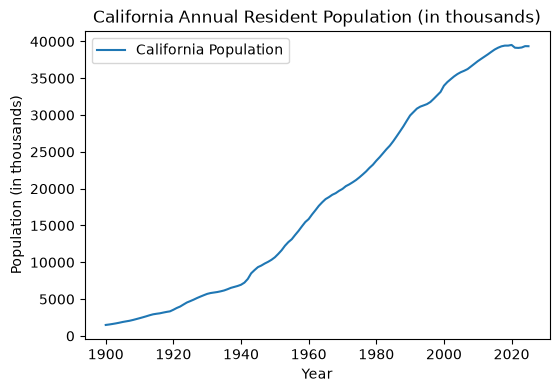

In [146]:
capop = pd.read_csv('CAPOP_29Sept2026.csv')
print(capop.head(10))
print(capop.tail(10))
tme = np.arange(1900, 2026)
plt.figure(figsize=(6, 4))
plt.plot(tme, capop['CAPOP'], label='California Population')
plt.xlabel('Year')
plt.ylabel('Population (in thousands)')
plt.title('California Annual Resident Population (in thousands)')
plt.legend()
plt.show()

We work with the logarithms of the population data as this will lead to models with better interpretability. 

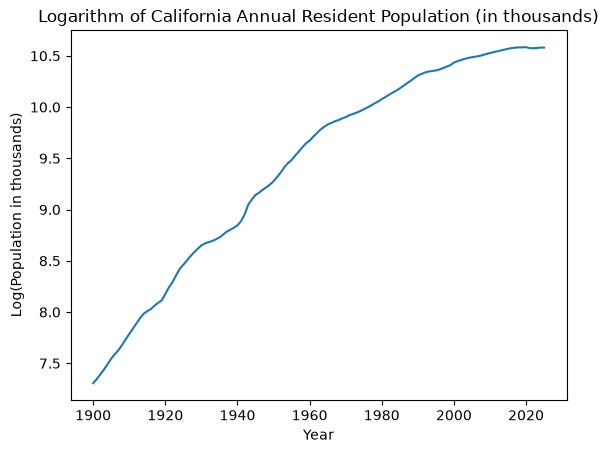

In [147]:
y = np.log(capop['CAPOP'])
n = len(y)
plt.plot(tme, y)
plt.xlabel('Year')
plt.ylabel('Log(Population in thousands)')
plt.title('Logarithm of California Annual Resident Population (in thousands)')
plt.show()

The first model we fit is linear regression: 
\begin{equation*}
   y_t = \beta_0 + \beta_1 t + \epsilon_t 
\end{equation*}
with $\epsilon_t$ being i.i.d $N(0, \sigma^2)$. $\beta_1$ here can be interpreted in terms of the overall growth rate. 

                            OLS Regression Results                            
Dep. Variable:                  CAPOP   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     2278.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.16e-81
Time:                        19:00:09   Log-Likelihood:                 8.2264
No. Observations:                 126   AIC:                            -12.45
Df Residuals:                     124   BIC:                            -6.780
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7387      0.041    188.952      0.0

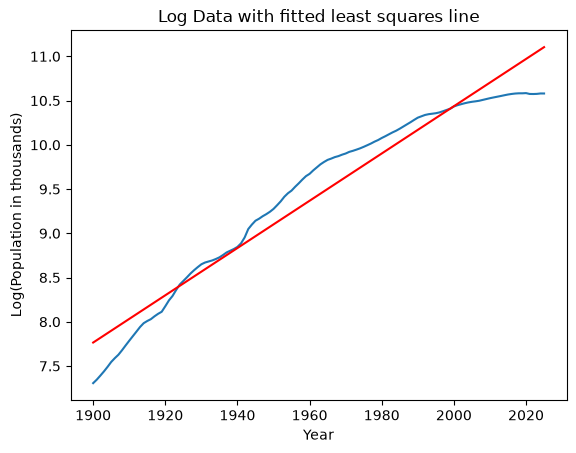

In [149]:
x = np.arange(1, n+1)
X = np.column_stack((np.ones(n), x))
linreg = sm.OLS(y, X).fit()
print(linreg.summary())
plt.plot(tme, y, label='Log(Population in thousands)')
plt.plot(tme, linreg.fittedvalues, color='red', label='Fitted least squares line')
plt.xlabel('Year')
plt.ylabel('Log(Population in thousands)')
plt.title('Log Data with fitted least squares line')
plt.show()

The fitted slope coefficient here is 0.0267. The interpretation is that the population increases by 2.67\% each year. 

### Broken-stick Regression or Change of Slope Model

The simple linear regression model obviously does not provide a good fit to the data. For an improved model, let us consider: 
\begin{equation*}
    y_t = \beta_0 + \beta_1 t + \beta_2 (t - c)_+ + \epsilon_t
\end{equation*}
This model uses $\beta_1$ for the slope before $c$, and $\beta_1 + \beta_2$ for the slope after $c$. We estimated $c$ by the following: 

1. For each fixed value of $c$, calculate RSS
2. Use the value of $c$ with the smallest RSS as the estimate

In [150]:
def rss(c):
    x = np.arange(1, n+1)
    x_c = np.maximum(0, x - c)
    X = np.column_stack((np.ones(n), x, x_c))
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

We compute $RSS(c)$ for each $c$ in a grid of values of $c$ as follows.

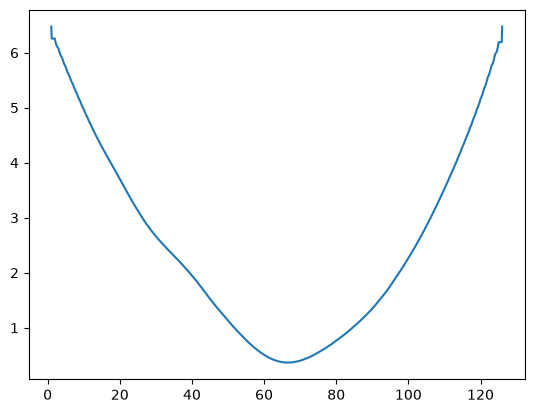

In [151]:
num_c_vals = 1000 #this is the number of different values of c we will try
allcvals = np.linspace(1, n, num_c_vals)
rssvals = np.array([rss(c) for c in allcvals])
plt.plot(allcvals, rssvals)
plt.show()

The estimate $\hat{c}$ is obtained by minimizing $RSS(c)$ as follows. 

In [153]:
c_hat = allcvals[np.argmin(rssvals)]
print(c_hat)
print(c_hat - 1 + tme[0]) #this is the estimated year when the slope changes
rss_smallest = np.min(rssvals)
print(rss_smallest)


66.56556556556558
1965.5655655655655
0.3677408605674205


The fitted values will now look much better than before. 

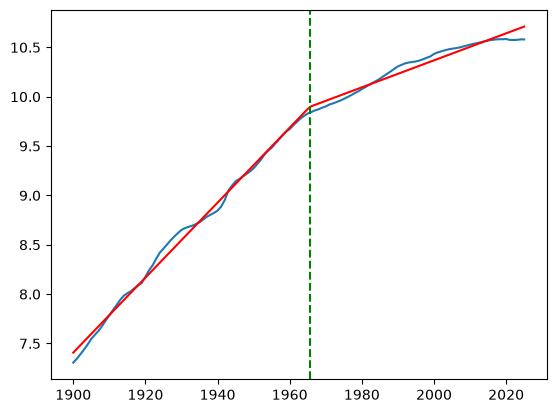

In [154]:
c = c_hat
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
md = sm.OLS(y, X).fit()
plt.plot(tme, y)
plt.plot(tme, md.fittedvalues, color = 'red')
plt.axvline(c_hat - 1 + tme[0], color='green', linestyle='--')
plt.show()

Point estimates of the other parameters $\beta_0, \beta_1, \beta_2$ are obtained as follows. 

In [155]:
#Estimates of other parameters: 
c = c_hat
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
md = sm.OLS(y, X).fit()
print(md.params) #this gives estimates of beta_0, beta_1, beta_2 

const    7.369872
x1       0.037974
x2      -0.024299
dtype: float64


The estimate of $\hat{\beta}_1$ is 0.038 and the estimate of $\hat{\beta}_2$ is $-0.024$. This means that the growth rate before 1965 was 3.8\% while the growth rate after 1965 is $3.8 - 2.4 = 1.4$\%. 

### Models with more changes of Slope

We can seek to obtain further improved models by using more points of change of slope. The following model has two points where the slope changes: 
\begin{align*}
   y_t = \beta_0 + \beta_1 t + \beta_2 (t - c_1)_+ + \beta_3 (t - c_2)_+ + \epsilon_t. 
\end{align*}
The unknown parameters now are $\beta_0,\beta_1, \beta_2, \beta_3$ as well as $c_1, c_2$ (also $\sigma$). 

For parameter estimation, we can define the RSS function: 
\begin{align*}
   RSS(c_1, c_2) := \min_{\beta_0, \beta_1, \beta_2, \beta_3} \sum_{t=1}^n \left(y_t - \beta_0 - \beta_1 t - \beta_2 (t - c_1)_+ - \beta_3 (t -c_2)_+ \right)^2
\end{align*}
and then we can do some sort of grid optimization for $c_1$ and $c_2$. The code for this is given below.

In [156]:
def rss(c): #c is now a vector of change of slope points
    n = len(y)
    x = np.arange(1, n+1)
    X = np.column_stack((np.ones(n), x))
    if np.isscalar(c):
        c = [c]
    for j in range(len(c)):
        x_c = np.maximum(0, x - c[j])
        X = np.column_stack((X, x_c))
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

In [157]:
num_c_vals = 200 #this is the number of different values of c we will try
c1_gr = np.linspace(1, n, num_c_vals)
c2_gr = np.linspace(1, n, num_c_vals)
C1, C2 = np.meshgrid(c1_gr, c2_gr)
g = pd.DataFrame({'c1': C1.ravel(), 'c2': C2.ravel()})
g['rss'] = g.apply(lambda row: rss([row['c1'], row['c2']]), axis=1)

min_row = g.loc[g['rss'].idxmin()]
print(min_row)
c_opt = min_row[:-1]
rss_opt = min_row.iloc[-1]
print(c_opt - 1 + tme[0]) #these are the estimated years when the slope changes
print(c_hat) #this was the best c in a single change of slope model
print(rss_smallest) #this was the smallest RSS in a single change of slope model
print(rss_opt)

c1     102.130653
c2      62.557789
rss      0.199761
Name: 19761, dtype: float64
c1    2001.130653
c2    1961.557789
Name: 19761, dtype: float64
66.56556556556558
0.3677408605674205
0.19976107958305042


                            OLS Regression Results                            
Dep. Variable:                  CAPOP   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.549e+04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          1.92e-170
Time:                        19:03:40   Log-Likelihood:                 227.37
No. Observations:                 126   AIC:                            -446.7
Df Residuals:                     122   BIC:                            -435.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3659      0.010    749.118      0.0

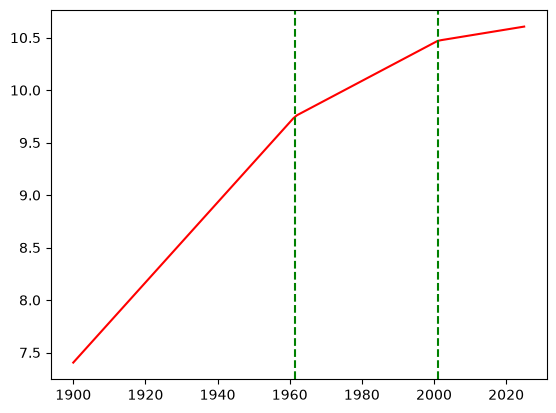

In [158]:
c = np.array(c_opt)
x = np.arange(1, n+1)
x_c1 = np.maximum(0, x - c[0])
x_c2 = np.maximum(0, x - c[1])
X = np.column_stack((np.ones(n), x, x_c1, x_c2))
md_2 = sm.OLS(y, X).fit()
print(md_2.summary())
#plt.plot(tme, y)
#plt.plot(tme, md.fittedvalues, color = 'orange', label='1 change of slope')
plt.plot(tme, md_2.fittedvalues, color = 'red')
plt.axvline(c[0] - 1 + tme[0], color='green', linestyle='--')
plt.axvline(c[1] - 1 + tme[0], color='green', linestyle='--')
plt.show()  

The interpretation of this model is that: before 1961, the growth rate is 3.82\%. Between 1961 and 2000, the growth fell to 3.82 - 1.26 = 2.56\%. After 2000, the growth rate further dropped to 2.56 - 2 = 0.56 \%. 

There is a different way of fitting this model that can be computationally more efficient. This involves jointly minimizing least squares over all the parameters. Specifically, we aim to optimize: 
\begin{align*}
   L(\beta_0, \beta_1, \beta_2, \beta_3, c_1, c_2) := \sum_{t=1}^n \left(y_t - \beta_0 - \beta_1 t - \beta_2 (t - c_1)_+ - \beta_3 (t - c_2)_+ \right)^2 
\end{align*}
over all the parameters $\beta_0, \beta_1, \beta_2, c_1, c_2$ simultaneously. This optimization is nonlinear and nontrivial but we can use black box optimization libraries. For example, we can use the pytorch library to solve this optimization.

First import the torch libraries. 

In [159]:
import torch
import torch.nn as nn
import torch.optim as optim

The following is the code for representing the broken stick regression (or change of slope) model in PyTorch. PyTorch organizes models as classes. 

In [160]:
class BrokenStickRegression(nn.Module):
    def __init__(self, knots_init, beta_init):
        super().__init__()
        self.num_knots = len(knots_init)
        self.beta = nn.Parameter(torch.tensor(beta_init, dtype=torch.float32))
        self.knots = nn.Parameter(torch.tensor(knots_init, dtype=torch.float32))

    def forward(self, x):
        knots_sorted,_ = torch.sort(self.knots)
        out = self.beta[0] + self.beta[1] * x
        for j in range(self.num_knots):
            out = out + self.beta[j+2] * torch.relu(x - knots_sorted[j])
        return out

The class `BrokenStickRegression` inherits from `nn.Module`, which is the base class for all models in PyTorch (linear regression, neural networks, etc.). By subclassing nn.Module, we get access to a lot of PyTorch functionality automatically: for example, it keeps track of parameters, makes them trainable, and allows us to use optimizers like gradient descent.

The term `knots` refers to $c_1, \dots, c_k$. 

In the constructor (`__init__`), the code takes two inputs: a list of initial knot positions (`knots_init`) and initial coefficients (`beta_init`). These are wrapped in `nn.Parameter`, which tells PyTorch: “this is a parameter we want to optimize.” So, during training, PyTorch will update both the regression coefficients and the knot locations.

The `forward` method defines the model equation (how does the model convert input $x$ to output $y$). When you pass in an input x, it:

1. Sorts the knot locations (so they are in order).

2. Starts with the base linear trend, $\beta_0 + \beta_1 x$

3. For each knot, adds a term $\beta_j \text{ReLU}(x - c_j)$

The effect is exactly the broken-stick regression function: linear to start, with slope changes at each knot. The nice thing about using `nn.Module` is that all of this can be trained with PyTorch’s optimization tools.

The raw data here is given by $y$ with covariate $x$ given by time $t = 1, \dots, n$. We do not apply the model to this raw data but we scale the raw data first. The algorithm for parameter fitting will work better with scaled data as opposed to raw data. 

The code below first standardizes the raw input arrays `y_raw` and `x_raw` by subtracting their means and dividing by their standard deviations, resulting in `y_scaled` and `x_scaled`, respectively. This scaling step ensures that both inputs have mean 0 and standard deviation 1, which helps neural network training converge faster and more reliably. After scaling, the arrays are converted into PyTorch tensors (`y_torch` and `x_torch`) with `dtype=torch.float32`, and an additional singleton dimension is added using `unsqueeze(1)` to ensure each data point is treated as a one-dimensional feature vector. Conversion to PyTorch tensors is necessary because PyTorch models and optimization routines (like gradient computation and parameter updates) operate on tensors, not on NumPy arrays.

In [161]:
y_raw = y
n = len(y_raw)
x_raw = np.arange(1, n+1)
y_scaled = (y_raw - np.mean(y_raw)) / np.std(y_raw)
x_scaled = (x_raw - np.mean(x_raw)) / np.std(x_raw)
y_torch = torch.tensor(y_scaled, dtype=torch.float32).unsqueeze(1)
x_torch = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(1)

For using PyTorch, the first step is to obtain suitable initial estimates for the parameters. These are deduced as follows. We take $c_1, \dots, c_k$ to be quantiles of the scaled covariate at equal levels. Then we fit the model with $c_1, \dots, c_k$ fixed at these initial values, and obtain the initial values of the coefficients. 

In [162]:
k = 2 #this is the number of knots (changes of slope)
quantile_levels = np.linspace(1/(k+1), k/(k+1), k)
knots_init = np.quantile(x_scaled, quantile_levels)

n = len(y_scaled)
X = np.column_stack((np.ones(n), x_scaled))
for j in range(k):
    x_c = np.maximum(0, x_scaled - knots_init[j])
    X = np.column_stack((X, x_c))
md_init = sm.OLS(y_scaled, X).fit()
beta_init = md_init.params.values
print(knots_init)
print(knots_init * np.std(x_raw) + np.mean(x_raw)) #these are the initial knots in original scale
print(beta_init)

[-0.57278616  0.57278616]
[42.66666667 84.33333333]
[ 0.48135629  1.48815313 -0.45562361 -0.68045908]


The next code line `md_nn = BrokenStickRegression(knots_init=knots_init, beta_init=beta_init)` creates an instance of the custom neural network model `BrokenStickRegression`. It initializes the learnable parameters of the model: the knot locations are set to the values provided in `knots_init`, and the coefficients are set to `beta_init`. This prepares the model for training by defining its initial piecewise linear structure.

In [163]:
md_nn = BrokenStickRegression(knots_init, beta_init)
#This code creates an instance of the BrokenStickRegression class with initial knots and beta values.

The next block of code sets up and runs the training loop for the model `BrokenStickRegression`. The `Adam` optimizer is initialized with the model’s parameters and a learning rate of 0.01, and the loss function is set to mean squared error (`MSELoss`). For 10,000 epochs, the code repeatedly performs one training step: it clears previous gradients with `optimizer.zero_grad()`, computes predictions `y_pred` by passing `x_torch` through the model, evaluates the loss between predictions and true values, backpropagates the loss with `loss.backward()`, and updates the model parameters using `optimizer.step()`. Every 100 epochs, the current epoch and loss value are printed to monitor training progress. Running the code multiple times may be necessary to ensure good convergence, especially because this is a non-convex optimization problem.

In [165]:
optimizer = optim.Adam(md_nn.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = md_nn(x_torch)
    loss = loss_fn(y_pred, y_torch)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.0015925031621009111
Epoch 500, Loss: 0.0015920239966362715
Epoch 1000, Loss: 0.001592024345882237
Epoch 1500, Loss: 0.0015920238802209496
Epoch 2000, Loss: 0.0015925345942378044
Epoch 2500, Loss: 0.0015925955958664417
Epoch 3000, Loss: 0.0015921215526759624
Epoch 3500, Loss: 0.0015965248458087444
Epoch 4000, Loss: 0.0015920241130515933
Epoch 4500, Loss: 0.001592024927958846
Epoch 5000, Loss: 0.0015920244622975588
Epoch 5500, Loss: 0.0015920245787128806
Epoch 6000, Loss: 0.0015920244622975588
Epoch 6500, Loss: 0.0015920235309749842
Epoch 7000, Loss: 0.0015920302830636501
Epoch 7500, Loss: 0.0015933793038129807
Epoch 8000, Loss: 0.0016028147656470537
Epoch 8500, Loss: 0.0015920246951282024
Epoch 9000, Loss: 0.0015920241130515933
Epoch 9500, Loss: 0.0015920239966362715


The next code prints out the current loss value, the estimated model coefficients (`beta`), and the estimated knot locations after training. The `detach().numpy()` calls are used to move each tensor from the computation graph to a regular NumPy array so they can be easily printed or further processed without tracking gradients. Finally, it prints `rss_opt`, which represents the smallest residual sum of squares (RSS) achieved with two knots using our previous grid-based search method. This provides a measure of the quality of the PyTorch parameter estimates. 


In [167]:
print(loss.detach().numpy())
print(md_nn.beta.detach().numpy())
print(md_nn.knots.detach().numpy())
print(rss_opt)

0.0015920238
[ 0.35588792  1.3921012  -0.72420883 -0.45621735]
[-0.03157811  1.0487218 ]
0.19976107958305042


`rss_opt` seems to be on a different scale to the loss. This is because of the change of scale when we went from `y_raw` and `x_raw` to `y_scaled` and `x_scaled`, as well as because the loss here is Mean-Squared Error (not just Squared Error). We can bring the loss to the same scale as RSS as follows. 

In [168]:
#converting back to original scale
print(loss.detach().numpy() * (np.std(y_raw)**2) * n ) #this rescales the loss to the rss scale
print(md_nn.beta.detach().numpy())
print(md_nn.knots.detach().numpy() * np.std(x_raw) + np.mean(x_raw)) #these are the knots in original scale
print(rss_opt)

0.1996371551927383
[ 0.35588792  1.3921012  -0.72420883 -0.45621735]
[ 62.35144338 101.64402653]
0.19976107958305042


The loss achieved by PyTorch seems slightly better than the RSS we got from our grid search method. This suggests that PyTorch is working well here. Next let us look at the estimates of $\beta_0, \dots, \beta_{k+1}$ obtained from PyTorch (converted to the original scale). We compare them with the estimates from our previous grid-search method.

In [169]:
#drop intercept
print(md_nn.beta.detach().numpy()[1:] * (np.std(y_raw)/np.std(x_raw)))
print(md_2.params.values[1:])

[ 0.03818257 -0.01986361 -0.01251314]
[ 0.03815355 -0.01255336 -0.019984  ]


This is essentially the same model that we found before (in the grid search method, $c_1$ and $c_2$ seem to be swapped though). 

This PyTorch method scales easily to higher values of the number of knots i.e., to fit models of the form: 
\begin{align*}
   y_t = \beta_0 + \beta_1 t + \beta_2 (t - c_1)_+ + \beta_3 (t - c_2)_+ + \dots + \beta_{k+1} (t - c_k)_+ + \epsilon_t
\end{align*}
On the other hand, the grid-search method will take very long to run. Below we fit the model with $k = 3$. 

In [177]:
k = 6 #this is the number of knots (changes of slope)
quantile_levels = np.linspace(1/(k+1), k/(k+1), k)
knots_init = np.quantile(x_scaled, quantile_levels)

n = len(y_scaled)
X = np.column_stack((np.ones(n), x_scaled))
for j in range(k):
    x_c = np.maximum(0, x_scaled - knots_init[j])
    X = np.column_stack((X, x_c))
md_init = sm.OLS(y_scaled, X).fit()
beta_init = md_init.params.values
print(knots_init)
print(knots_init * np.std(x_raw) + np.mean(x_raw)) #these are the initial knots in original scale
print(beta_init)

[-1.22739892 -0.73643935 -0.24547978  0.24547978  0.73643935  1.22739892]
[ 18.85714286  36.71428571  54.57142857  72.42857143  90.28571429
 108.14285714]
[ 0.86633443  1.74925369 -0.50458691  0.16019777 -0.39630201 -0.34868515
 -0.14694489 -0.36487881]


In [178]:
md_nn_k = BrokenStickRegression(knots_init, beta_init)
#This code creates an instance of the BrokenStickRegression class with initial knots and beta values.

In [179]:
optimizer = optim.Adam(md_nn_k.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = md_nn_k(x_torch)
    loss = loss_fn(y_pred, y_torch)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.0011327910469844937
Epoch 500, Loss: 0.0004229986807331443
Epoch 1000, Loss: 0.00035374544677324593
Epoch 1500, Loss: 0.0003272918111179024
Epoch 2000, Loss: 0.00031581372604705393
Epoch 2500, Loss: 0.00031160947401076555
Epoch 3000, Loss: 0.0003096174623351544
Epoch 3500, Loss: 0.00030928454361855984
Epoch 4000, Loss: 0.00030810970929451287
Epoch 4500, Loss: 0.0003078346198890358
Epoch 5000, Loss: 0.0003078820009250194
Epoch 5500, Loss: 0.0003075877029914409
Epoch 6000, Loss: 0.00030752806924283504
Epoch 6500, Loss: 0.00030754992621950805
Epoch 7000, Loss: 0.0003074596752412617
Epoch 7500, Loss: 0.0003074312990065664
Epoch 8000, Loss: 0.0003074094420298934
Epoch 8500, Loss: 0.000307392911054194
Epoch 9000, Loss: 0.00030737632187083364
Epoch 9500, Loss: 0.0003073618281632662


The estimates of the knots are given below. 

In [180]:
c_est = md_nn_k.knots.detach().numpy() * np.std(x_raw) + np.mean(x_raw)
print(c_est)

[ 29.95563226  38.27802863  59.08876163  63.65471383  94.58710829
 113.89943503]


The rss value and the fitted values are computed as below. 

In [181]:
c = c_est
x = np.arange(1, n+1)
X = np.column_stack((np.ones(n), x))
if np.isscalar(c):
    c = [c]
for j in range(len(c)):
    x_c = np.maximum(0, x - c[j])
    X = np.column_stack((X, x_c))
md_k = sm.OLS(y, X).fit() 
rss_k = np.sum(md_k.resid ** 2)
print(rss_k)

0.038539956283362334


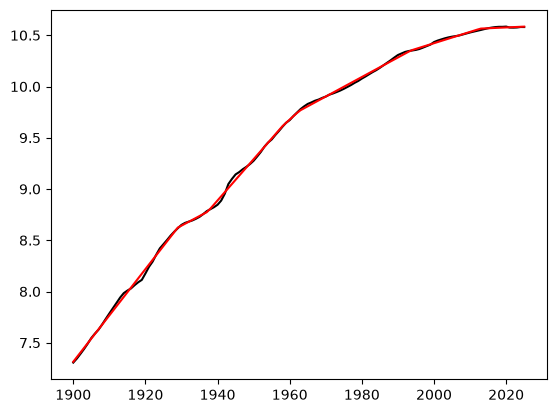

In [183]:
plt.plot(tme, y, color= 'black')
#plt.plot(tme, md_2.fittedvalues, color = 'blue', label='2 changes of slope')
plt.plot(tme, md_k.fittedvalues, color = 'red', label = 'k changes of slope')
#plt.axvline(c[0] - 1 + tme[0], color='green', linestyle='--')
#plt.axvline(c[1] - 1 + tme[0], color='green', linestyle='--')
plt.show()  

The fitted values from the $k = 3$ model seem to be quite close to the fitted values for the $k = 2$ model. Go back and run the method for $k = 6$. This should lead to overfitting and the fitted values will look a lot like the data. 

## Importance of Initialization

This method based on PyTorch requires careful initialization. This can be seen from the following simple simulated example. 

In [184]:
rng = np.random.default_rng(1)
n = 400
x = np.arange(1, n + 1)

y_true = 0.6 * (
    np.maximum(0, x - 40)
    - 2 * np.maximum(0, x - 50)
    + np.maximum(0, x - 60)
)
sig_noise = 0.4
y = y_true + sig_noise * rng.standard_normal(n)


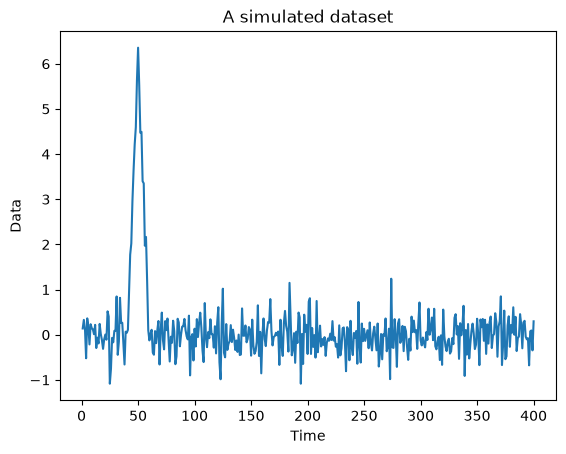

In [185]:
n = len(y)
tme = np.arange(1, n + 1)
plt.plot(tme, y)
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('A simulated dataset')
plt.show()

In [186]:
y_raw = y
n = len(y_raw)
x_raw = np.arange(1, n + 1)

y_scaled = (y_raw - np.mean(y_raw)) / np.std(y_raw)
x_scaled = (x_raw - np.mean(x_raw)) / np.std(x_raw)

y_torch = torch.tensor(y_scaled, dtype=torch.float32).unsqueeze(1)
x_torch = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(1)

In [196]:
k = 3
quantile_levels = np.linspace(1 / (k + 1), k / (k + 1), k)
knots_init = np.quantile(x_scaled, quantile_levels)

#Better initialization: 
c_init = np.array([38., 55., 62.])
knots_init = (c_init - np.mean(x_raw)) / np.std(x_raw)


In [197]:
n = len(y_scaled)
X = np.column_stack((np.ones(n), x_scaled))
for j in range(k):
    x_c = np.maximum(0, x_scaled - knots_init[j])
    X = np.column_stack((X, x_c))

md_init = sm.OLS(y_scaled, X).fit()
beta_init = np.asarray(md_init.params)

print(knots_init)
print(knots_init * np.std(x_raw) + np.mean(x_raw))
print(beta_init)


[-1.40729568 -1.2600709  -1.19944893]
[38. 55. 62.]
[   1.67032957    1.10106531   36.13272113 -133.93530714   96.74733646]


In [198]:
md_nn_k = BrokenStickRegression(knots_init, beta_init)

optimizer = optim.Adam(md_nn_k.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(100000):
    optimizer.zero_grad()
    y_pred = md_nn_k(x_torch)
    loss = loss_fn(y_pred, y_torch)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')


Epoch 0, Loss: 0.3337884843349457
Epoch 500, Loss: 0.2502412497997284
Epoch 1000, Loss: 0.2500342130661011
Epoch 1500, Loss: 0.25066688656806946
Epoch 2000, Loss: 0.2502841055393219
Epoch 2500, Loss: 0.24942947924137115
Epoch 3000, Loss: 0.24923084676265717
Epoch 3500, Loss: 0.24903494119644165
Epoch 4000, Loss: 0.24883756041526794
Epoch 4500, Loss: 0.24873390793800354
Epoch 5000, Loss: 0.24844516813755035
Epoch 5500, Loss: 0.24862927198410034
Epoch 6000, Loss: 0.2480580359697342
Epoch 6500, Loss: 0.2478664070367813
Epoch 7000, Loss: 0.247695654630661
Epoch 7500, Loss: 0.24748843908309937
Epoch 8000, Loss: 0.2473001331090927
Epoch 8500, Loss: 0.24711519479751587
Epoch 9000, Loss: 0.24692924320697784
Epoch 9500, Loss: 0.2467452883720398
Epoch 10000, Loss: 0.24655698239803314
Epoch 10500, Loss: 0.24696698784828186
Epoch 11000, Loss: 0.2461887001991272
Epoch 11500, Loss: 0.2460019290447235
Epoch 12000, Loss: 0.24582156538963318
Epoch 12500, Loss: 0.24564018845558167
Epoch 13000, Loss: 0.2

In [199]:
c_est = md_nn_k.knots.detach().numpy() * np.std(x_raw) + np.mean(x_raw)
print(c_est)

[37.2653834  51.78968288 59.48162598]


60.99424395355864


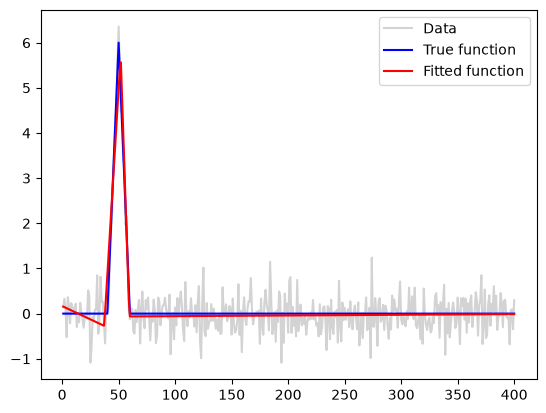

In [200]:
c = c_est
x = np.arange(1, n + 1)
X = np.column_stack((np.ones(n), x))
if np.isscalar(c):
    c = [c]
for j in range(len(c)):
    x_c = np.maximum(0, x - c[j])
    X = np.column_stack((X, x_c))

md_k = sm.OLS(y, X).fit()
rss_k = np.sum(md_k.resid ** 2)
print(rss_k)

plt.plot(x, y, color='lightgray', label='Data')
plt.plot(x, y_true, color='blue', label='True function')
plt.plot(x, md_k.fittedvalues, color='red', label='Fitted function')
plt.legend()
plt.show()

## High-dimensional Linear Regression and Regularization

We now consider the model:
\begin{equation*}
  y_t = \beta_0 + \beta_1 (t - 1) + \beta_2 (t - 2)_+ + \beta_3 (t - 3)_+ + \dots + \beta_{n-1} (t - (n-1))_+ + \epsilon_t
\end{equation*}
We can write this as
\begin{equation*}
   y = X_{\text{full}} \beta + \epsilon
\end{equation*}
where $X_{\text{full}}$ is constructed as below. 

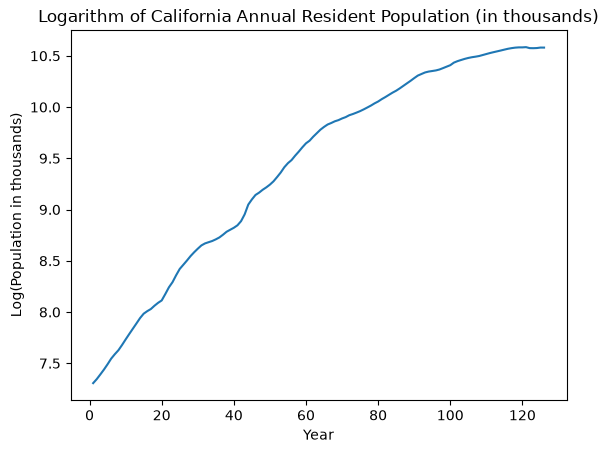

In [202]:
y = np.log(capop['CAPOP'])
n = len(y)
tme = np.arange(1, n+1)
plt.plot(tme, y)
plt.xlabel('Year')
plt.ylabel('Log(Population in thousands)')
plt.title('Logarithm of California Annual Resident Population (in thousands)')
plt.show()


In [203]:
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[  1.   0.  -0. ...  -0.  -0.  -0.]
 [  1.   1.   0. ...  -0.  -0.  -0.]
 [  1.   2.   1. ...  -0.  -0.  -0.]
 ...
 [  1. 123. 122. ...   1.   0.  -0.]
 [  1. 124. 123. ...   2.   1.   0.]
 [  1. 125. 124. ...   3.   2.   1.]]


If we fit this model without any regularization, we get the following. 

In [204]:
mdfull = sm.OLS(y, Xfull).fit()
print(mdfull.summary())

                            OLS Regression Results                            
Dep. Variable:                  CAPOP   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 29 Sep 2026   Prob (F-statistic):                nan
Time:                        19:48:05   Log-Likelihood:                 3207.8
No. Observations:                 126   AIC:                            -6164.
Df Residuals:                       0   BIC:                            -5806.
Df Model:                         125                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3065        inf          0        n

/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In this unregularized estimation, the estimate of $\beta_0$ equals $y_1$, the estimate of $\beta_1$ is $y_2 - y_1$, and the estimate of $\beta_j$ is $y_{j+1} - 2 y_j + y_{j-1}$ for $j = 2, \dots, n-1$. Let us check this. 

In [205]:
print(y[0])
print(y[1] - y[0])
print(y[2] - y[1] - y[1] + y[0])
print(mdfull.params)

7.306531398939505
0.03947881097378758
0.006542546627510859
const    7.306531
x1       0.039479
x2       0.006543
x3       0.001506
x4       0.004001
           ...   
x121    -0.011814
x122     0.008825
x123     0.002143
x124     0.003224
x125    -0.004903
Length: 126, dtype: float64


We shall study regularization in the next lecture.